# Notebook 07: Genre Performance Across Platforms

## Research Question 5

**How does the performance of video game genres vary across different platforms?**

## Objective

This notebook examines how video game genres perform across gaming platforms.

Rather than evaluating genres or platforms independently, the analysis focuses on the relationship between them. This helps identify which genre-platform combinations generated the strongest sales and whether certain genres performed particularly well on specific platforms.

The analysis will consider both total global sales and the number of games released. Average sales per game will also be examined so that combinations with large game libraries are not automatically treated as the strongest performers.

## Analysis Overview

This notebook will examine:

1. The number of games released for each genre-platform combination
2. Total global sales by genre and platform
3. Average global sales per game
4. The strongest genre-platform combinations
5. Genre performance across selected major platforms
6. The balance between release volume and sales performance

The notebook will conclude with a brief interpretation of the main findings and how they contribute to the broader video game sales analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [2]:
candidate_paths = [
    Path("../../data/processed/video_game_sales_cleaned.csv"),
    Path("../data/processed/video_game_sales_cleaned.csv"),
    Path("data/processed/video_game_sales_cleaned.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find video_game_sales_cleaned.csv. "
        "Update candidate_paths to match the notebook's location."
    )

df = pd.read_csv(data_path)

print(f"Loaded: {data_path.resolve()}")
print(f"Dataset shape: {df.shape}")
df.head()

Loaded: C:\Users\tyler\OneDrive\Desktop\26projects\data_an\data-analysis-on-the-videogame-industry\data\processed\video_game_sales_cleaned.csv
Dataset shape: (16287, 19)


,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,regional_sales_total,decade,sales_tier,is_high_seller,na_sales_share,eu_sales_share,jp_sales_share,other_sales_share,dominant_region
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,2000s,blockbuster,1,0.501450,0.350737,0.045564,0.102248,North America
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,1980s,blockbuster,1,0.722664,0.088966,0.169235,0.019135,North America
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,2000s,blockbuster,1,0.442367,0.359475,0.105777,0.092381,North America
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,2000s,blockbuster,1,0.477273,0.333636,0.099394,0.089697,North America
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,1990s,blockbuster,1,0.359146,0.283301,0.325685,0.031867,North America


In [3]:
analysis_df = df[
    ["name", "platform", "genre", "global_sales"]
].copy()

analysis_df = analysis_df.dropna(
    subset=["platform", "genre", "global_sales"]
)

print(f"Analysis dataset shape: {analysis_df.shape}")

analysis_df.head()

Analysis dataset shape: (16287, 4)


,name,platform,genre,global_sales
0,Wii Sports,Wii,Sports,82.74
1,Super Mario Bros.,NES,Platform,40.24
2,Mario Kart Wii,Wii,Racing,35.82
3,Wii Sports Resort,Wii,Sports,33.00
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37


In [4]:
print(analysis_df.dtypes)

print(f"\nUnique platforms: {analysis_df['platform'].nunique()}")
print(f"Unique genres: {analysis_df['genre'].nunique()}")

name                str
platform            str
genre               str
global_sales    float64
dtype: object

Unique platforms: 31
Unique genres: 12


In [5]:
genre_platform_summary = (
    analysis_df
    .groupby(["platform", "genre"])
    .agg(
        game_count=("name", "count"),
        total_global_sales=("global_sales", "sum"),
        average_global_sales=("global_sales", "mean"),
        median_global_sales=("global_sales", "median")
    )
    .reset_index()
)

# Round sales values for readability
sales_columns = [
    "total_global_sales",
    "average_global_sales",
    "median_global_sales"
]

genre_platform_summary[sales_columns] = (
    genre_platform_summary[sales_columns].round(2)
)

genre_platform_summary.head(10)

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
0,2600,Action,55,26.39,0.48,0.38
1,2600,Adventure,1,0.40,0.40,0.40
2,2600,Fighting,1,0.77,0.77,0.77
3,2600,Misc,5,3.58,0.72,0.87
4,2600,Platform,9,13.27,1.47,1.10
5,2600,Puzzle,8,13.65,1.71,0.68
6,2600,Racing,4,2.32,0.58,0.44
7,2600,Shooter,22,22.97,1.04,0.75
8,2600,Simulation,1,0.45,0.45,0.45
9,2600,Sports,10,2.77,0.28,0.24


In [6]:
# Keep combinations with enough games for a more reliable comparison
minimum_games = 10

reliable_combinations = genre_platform_summary[
    genre_platform_summary["game_count"] >= minimum_games
].copy()

print(f"Genre-platform combinations with at least {minimum_games} games:")
print(reliable_combinations.shape[0])

Genre-platform combinations with at least 10 games:
207


In [7]:
top_total_sales = (
    reliable_combinations
    .sort_values("total_global_sales", ascending=False)
    .head(15)
)

top_total_sales

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
153,PS3,Action,373,304.02,0.82,0.32
244,Wii,Sports,256,289.95,1.13,0.23
266,X360,Shooter,197,277.23,1.41,0.41
141,PS2,Action,345,272.43,0.79,0.36
151,PS2,Sports,391,262.64,0.67,0.31
258,X360,Action,318,239.67,0.75,0.30
237,Wii,Misc,272,217.43,0.80,0.24
161,PS3,Shooter,155,195.80,1.26,0.57
147,PS2,Racing,212,154.21,0.73,0.26
37,DS,Misc,389,137.67,0.35,0.10


In [8]:
top_average_sales = (
    reliable_combinations
    .sort_values("average_global_sales", ascending=False)
    .head(15)
)

top_average_sales

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
52,GB,Role-Playing,21,88.24,4.20,0.76
108,NES,Platform,28,95.78,3.42,1.18
50,GB,Puzzle,15,47.47,3.16,1.15
49,GB,Platform,18,53.88,2.99,2.20
222,SNES,Platform,26,65.65,2.53,0.60
173,PS4,Shooter,34,75.32,2.22,1.26
104,NES,Action,13,28.75,2.21,1.64
113,NES,Sports,14,26.85,1.92,2.05
111,NES,Role-Playing,11,18.78,1.71,1.25
238,Wii,Platform,57,90.68,1.59,0.33


In [9]:
top_game_count = (
    reliable_combinations
    .sort_values("game_count", ascending=False)
    .head(15)
)

top_game_count

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
151,PS2,Sports,391,262.64,0.67,0.31
37,DS,Misc,389,137.67,0.35,0.10
153,PS3,Action,373,304.02,0.82,0.32
141,PS2,Action,345,272.43,0.79,0.36
34,DS,Action,335,114.16,0.34,0.12
258,X360,Action,318,239.67,0.75,0.30
43,DS,Simulation,279,131.36,0.47,0.12
237,Wii,Misc,272,217.43,0.80,0.24
244,Wii,Sports,256,289.95,1.13,0.23
35,DS,Adventure,238,47.15,0.20,0.08


### 1. Top Genre–Platform Combinations by Total Global Sales

The following chart shows the genre-platform combinations that generated the greatest total global sales.

This measure reflects overall commercial contribution, but it may favour combinations with a large number of game releases.

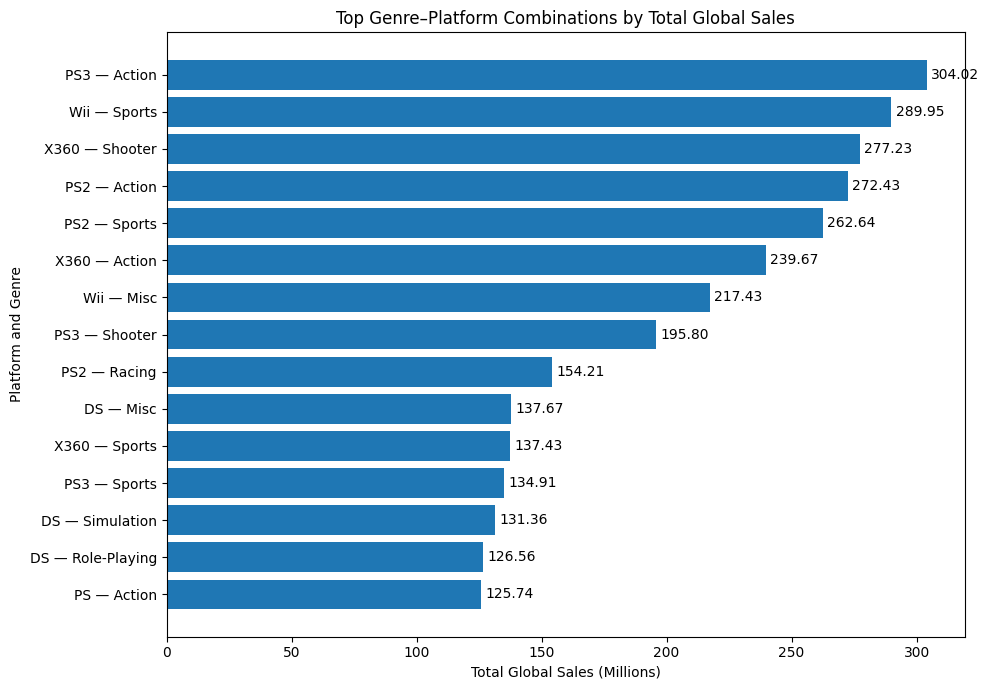

In [10]:
top_total_sales = top_total_sales.copy()

top_total_sales["genre_platform"] = (
    top_total_sales["platform"]
    + " — "
    + top_total_sales["genre"]
)

plot_data = top_total_sales.sort_values(
    "total_global_sales",
    ascending=True
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    plot_data["genre_platform"],
    plot_data["total_global_sales"]
)

plt.bar_label(bars, fmt="%.2f", padding=3)

plt.title("Top Genre–Platform Combinations by Total Global Sales")
plt.xlabel("Total Global Sales (Millions)")
plt.ylabel("Platform and Genre")

plt.tight_layout()
plt.show()

### 2. Top Genre–Platform Combinations by Average Global Sales

Total sales can be heavily influenced by the number of games released. Average global sales per game provides a different perspective by measuring the typical sales performance of each genre-platform combination.

Only combinations with at least 10 games are included to reduce the influence of small groups and individual blockbuster titles.

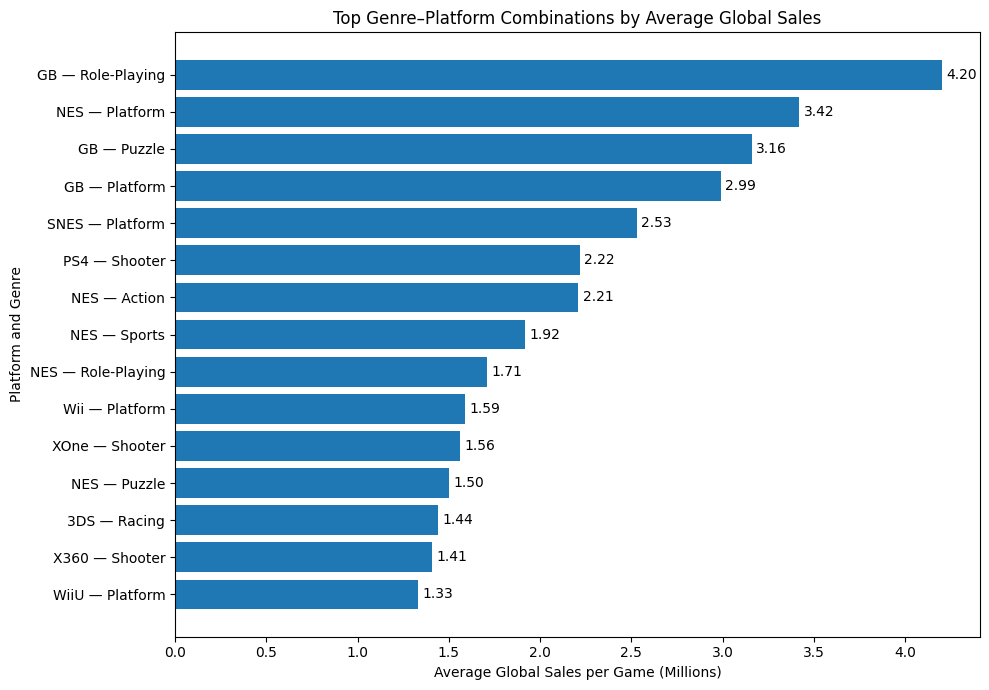

In [11]:
top_average_sales = (
    reliable_combinations
    .sort_values("average_global_sales", ascending=False)
    .head(15)
    .copy()
)

top_average_sales["genre_platform"] = (
    top_average_sales["platform"]
    + " — "
    + top_average_sales["genre"]
)

plot_data = top_average_sales.sort_values(
    "average_global_sales",
    ascending=True
)

plt.figure(figsize=(10, 7))

# Store the container returned by plt.barh
bars = plt.barh(
    plot_data["genre_platform"],
    plot_data["average_global_sales"]
)

# Add values next to the bars
plt.bar_label(bars, fmt="%.2f", padding=3)

plt.title("Top Genre–Platform Combinations by Average Global Sales")
plt.xlabel("Average Global Sales per Game (Millions)")
plt.ylabel("Platform and Genre")

plt.tight_layout()
plt.show()

### 3. Most Common Genre–Platform Combinations

The number of games released shows which genre-platform combinations were most heavily represented in the dataset.

Comparing release volume with total and average sales helps determine whether a combination's commercial performance was driven by a large catalogue or by stronger sales per individual game.

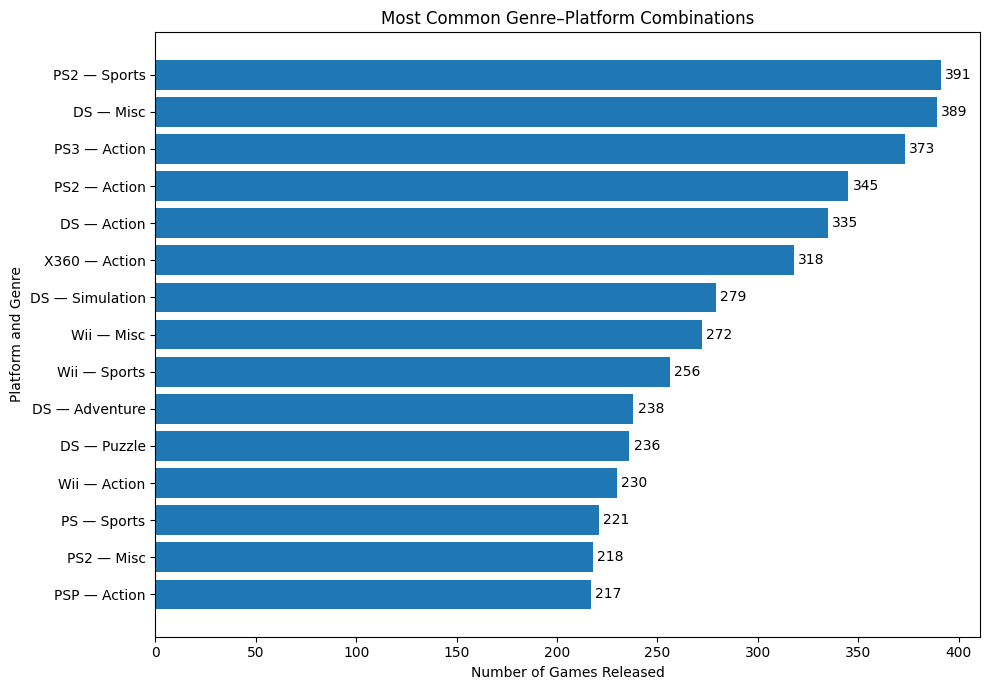

In [12]:
top_game_count = (
    reliable_combinations
    .sort_values("game_count", ascending=False)
    .head(15)
    .copy()
)

top_game_count["genre_platform"] = (
    top_game_count["platform"]
    + " — "
    + top_game_count["genre"]
)

plot_data = top_game_count.sort_values(
    "game_count",
    ascending=True
)

plt.figure(figsize=(10, 7))

# Store the bar container
bars = plt.barh(
    plot_data["genre_platform"],
    plot_data["game_count"]
)

# Add whole number labels next to the bars
plt.bar_label(bars, fmt="%d", padding=3)

plt.title("Most Common Genre–Platform Combinations")
plt.xlabel("Number of Games Released")
plt.ylabel("Platform and Genre")

plt.tight_layout()
plt.show()

## 4. Comparison of Sales Volume and Sales Efficiency

The following table combines total sales, average sales, and release volume for the leading genre-platform combinations.

This comparison helps identify whether strong total sales were primarily associated with:

- A large number of releases
- High average sales per game
- A combination of both factors

In [13]:
comparison_table = (
    reliable_combinations
    .sort_values("total_global_sales", ascending=False)
    .head(20)
    [
        [
            "platform",
            "genre",
            "game_count",
            "total_global_sales",
            "average_global_sales",
            "median_global_sales"
        ]
    ]
)

comparison_table

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
153,PS3,Action,373,304.02,0.82,0.32
244,Wii,Sports,256,289.95,1.13,0.23
266,X360,Shooter,197,277.23,1.41,0.41
141,PS2,Action,345,272.43,0.79,0.36
151,PS2,Sports,391,262.64,0.67,0.31
258,X360,Action,318,239.67,0.75,0.30
237,Wii,Misc,272,217.43,0.80,0.24
161,PS3,Shooter,155,195.80,1.26,0.57
147,PS2,Racing,212,154.21,0.73,0.26
37,DS,Misc,389,137.67,0.35,0.10


## 5. Genre Performance Across Platforms

A heatmap provides a broader view of how genres performed across platforms.

The first heatmap compares total global sales. Darker cells represent genre-platform combinations with greater accumulated sales.

Because total sales are influenced by both game performance and the number of releases, this chart should be interpreted alongside the average-sales heatmap.

In [14]:
# Create a platform-by-genre table using total global sales
total_sales_pivot = (
    analysis_df
    .pivot_table(
        index="platform",
        columns="genre",
        values="global_sales",
        aggfunc="sum",
        fill_value=0
    )
)

# Rank platforms by total sales and keep the 15 largest
top_platforms = (
    analysis_df
    .groupby("platform")["global_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

total_sales_pivot = total_sales_pivot.loc[top_platforms]

total_sales_pivot.round(2)

genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
platform,,,,,,,,,,,,
PS2,272.43,21.16,89.19,98.69,72.11,5.90,154.21,91.55,108.28,42.26,262.64,15.04
X360,239.67,15.23,37.64,89.33,11.39,0.71,65.13,71.97,277.23,14.10,137.43,9.77
PS3,304.02,22.87,51.70,45.91,29.85,0.46,73.10,75.24,195.80,10.72,134.91,4.77
Wii,110.48,18.33,23.82,217.43,90.68,15.63,61.24,14.06,26.34,36.62,289.95,5.23
DS,114.16,47.15,7.20,137.67,77.40,83.87,38.58,126.56,8.20,131.36,31.71,14.76
PS,125.74,20.77,72.68,44.90,64.21,12.08,102.89,78.30,39.31,25.33,119.51,21.67
GBA,54.26,12.10,4.21,28.50,78.08,12.09,18.80,64.21,3.60,5.91,16.41,7.45
PSP,62.66,10.69,21.88,13.70,17.28,5.52,34.73,49.01,19.77,6.28,39.90,10.29
PS4,87.06,4.70,8.04,7.40,7.01,0.02,11.53,25.74,75.32,0.77,50.07,0.41


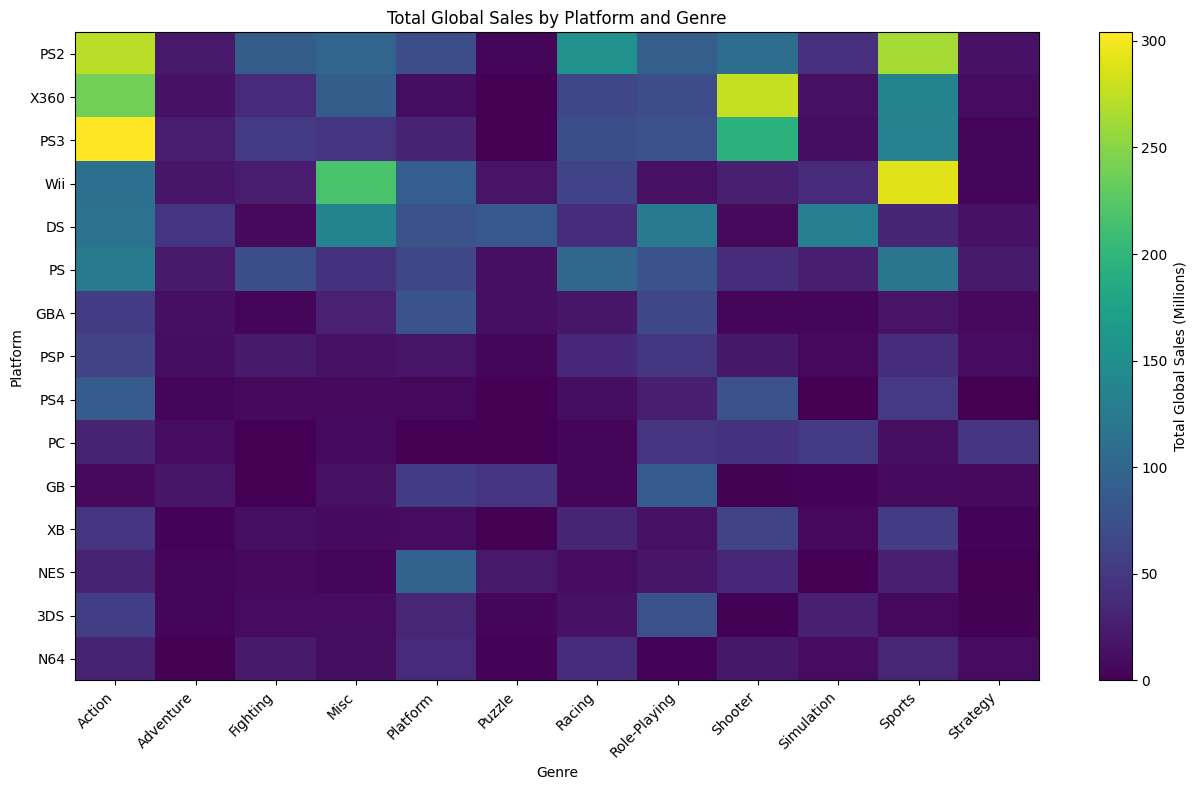

In [15]:
# Plot the total-sales heatmap using Matplotlib
fig, ax = plt.subplots(figsize=(13, 8))

heatmap = ax.imshow(
    total_sales_pivot.values,
    aspect="auto"
)

ax.set_xticks(range(len(total_sales_pivot.columns)))
ax.set_xticklabels(
    total_sales_pivot.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(total_sales_pivot.index)))
ax.set_yticklabels(total_sales_pivot.index)

ax.set_title("Total Global Sales by Platform and Genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Platform")

colorbar = fig.colorbar(heatmap, ax=ax)
colorbar.set_label("Total Global Sales (Millions)")

plt.tight_layout()
plt.show()

### 6. Average Sales per Game Across Platforms and Genres

The next heatmap compares average global sales per game.

This measure reduces the influence of release volume and helps identify combinations where individual games generally performed well.

To avoid unstable averages, only genre-platform combinations with at least 10 games are included. Combinations below this threshold are displayed as missing values.

In [16]:
# Create a table containing game count for every combination
game_count_pivot = (
    analysis_df
    .pivot_table(
        index="platform",
        columns="genre",
        values="name",
        aggfunc="count",
        fill_value=0
    )
)

# Create a table containing average sales for every combination
average_sales_pivot = (
    analysis_df
    .pivot_table(
        index="platform",
        columns="genre",
        values="global_sales",
        aggfunc="mean"
    )
)

# Keep the same leading platforms used in the total-sales heatmap
average_sales_pivot = average_sales_pivot.loc[top_platforms]
game_count_pivot = game_count_pivot.loc[top_platforms]

# Hide combinations represented by fewer than the minimum number of games
average_sales_filtered = average_sales_pivot.where(
    game_count_pivot >= minimum_games
)

average_sales_filtered.round(2)

genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
platform,,,,,,,,,,,,
PS2,0.79,0.11,0.61,0.45,0.71,0.33,0.73,0.50,0.69,0.47,0.67,0.21
X360,0.75,0.32,0.58,0.73,0.47,NaN,0.64,0.96,1.41,0.39,0.64,0.36
PS3,0.82,0.32,0.68,0.38,0.83,NaN,0.81,0.64,1.26,0.36,0.64,0.22
Wii,0.48,0.22,0.58,0.80,1.59,0.29,0.67,0.40,0.43,0.44,1.13,0.21
DS,0.34,0.20,0.20,0.35,0.87,0.36,0.58,0.65,0.20,0.47,0.22,0.19
PS,0.82,0.31,0.67,0.59,1.00,0.38,0.71,0.81,0.41,0.42,0.54,0.31
GBA,0.33,0.34,0.18,0.33,0.56,0.31,0.29,0.88,0.09,0.33,0.19,0.41
PSP,0.29,0.05,0.30,0.13,0.48,0.13,0.53,0.26,0.53,0.22,0.31,0.18
PS4,0.71,0.25,0.47,0.49,0.64,NaN,0.68,0.56,2.22,NaN,1.16,NaN


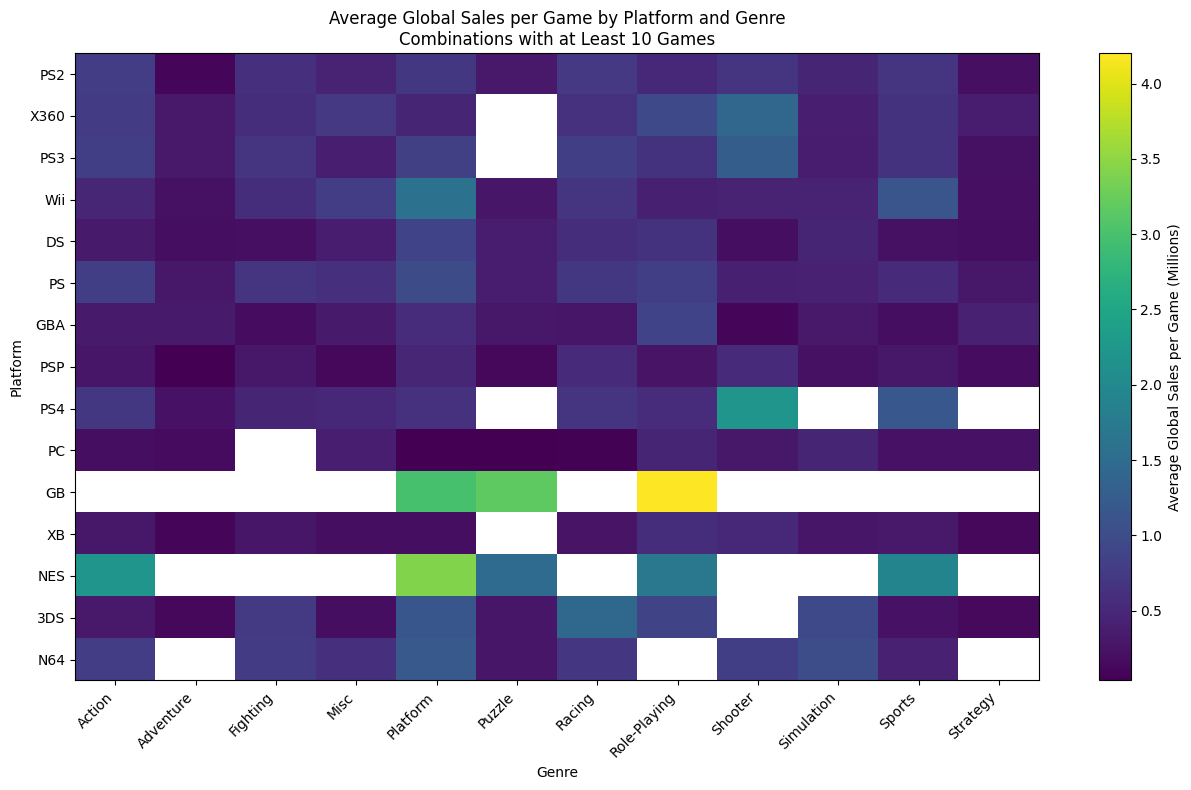

In [17]:
# Plot the average-sales heatmap
fig, ax = plt.subplots(figsize=(13, 8))

heatmap = ax.imshow(
    average_sales_filtered.values,
    aspect="auto"
)

ax.set_xticks(range(len(average_sales_filtered.columns)))
ax.set_xticklabels(
    average_sales_filtered.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(average_sales_filtered.index)))
ax.set_yticklabels(average_sales_filtered.index)

ax.set_title(
    f"Average Global Sales per Game by Platform and Genre\n"
    f"Combinations with at Least {minimum_games} Games"
)
ax.set_xlabel("Genre")
ax.set_ylabel("Platform")

colorbar = fig.colorbar(heatmap, ax=ax)
colorbar.set_label("Average Global Sales per Game (Millions)")

plt.tight_layout()
plt.show()

## 7. Genre Composition of Major Platforms

The following analysis examines the genre composition of the largest platforms.

Rather than comparing raw sales alone, each genre's sales are converted into a percentage of the platform's total global sales.

This shows which genres contributed most strongly to each platform and makes platforms of different sizes easier to compare.

In [18]:
# Select the 10 platforms with the greatest total global sales
major_platforms = (
    analysis_df
    .groupby("platform")["global_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

major_platform_data = analysis_df[
    analysis_df["platform"].isin(major_platforms)
].copy()

# Calculate total sales for each platform-genre combination
platform_genre_sales = (
    major_platform_data
    .groupby(["platform", "genre"], as_index=False)
    .agg(
        total_global_sales=("global_sales", "sum")
    )
)

# Calculate total sales for each platform
platform_totals = (
    platform_genre_sales
    .groupby("platform")["total_global_sales"]
    .transform("sum")
)

# Calculate each genre's percentage of its platform's total sales
platform_genre_sales["sales_share"] = (
    platform_genre_sales["total_global_sales"]
    / platform_totals
    * 100
)

platform_genre_sales.head()

,platform,genre,total_global_sales,sales_share
0,DS,Action,114.16,13.945420
1,DS,Adventure,47.15,5.759693
2,DS,Fighting,7.20,0.879529
3,DS,Misc,137.67,16.817327
4,DS,Platform,77.40,9.454936


In [19]:
# Create a platform-by-genre table using percentage of platform sales
sales_share_pivot = (
    platform_genre_sales
    .pivot(
        index="platform",
        columns="genre",
        values="sales_share"
    )
    .fillna(0)
)

# Keep platforms ordered by total global sales
sales_share_pivot = sales_share_pivot.loc[major_platforms]

sales_share_pivot.round(2)

genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
platform,,,,,,,,,,,,
PS2,22.09,1.72,7.23,8.00,5.85,0.48,12.50,7.42,8.78,3.43,21.29,1.22
X360,24.72,1.57,3.88,9.21,1.17,0.07,6.72,7.42,28.59,1.45,14.17,1.01
PS3,32.02,2.41,5.45,4.84,3.14,0.05,7.70,7.93,20.62,1.13,14.21,0.50
Wii,12.14,2.01,2.62,23.90,9.97,1.72,6.73,1.55,2.90,4.03,31.87,0.57
DS,13.95,5.76,0.88,16.82,9.45,10.25,4.71,15.46,1.00,16.05,3.87,1.80
PS,17.29,2.86,9.99,6.17,8.83,1.66,14.15,10.76,5.40,3.48,16.43,2.98
GBA,17.75,3.96,1.38,9.33,25.55,3.96,6.15,21.01,1.18,1.93,5.37,2.44
PSP,21.48,3.66,7.50,4.70,5.92,1.89,11.91,16.80,6.78,2.15,13.68,3.53
PS4,31.31,1.69,2.89,2.66,2.52,0.01,4.15,9.26,27.09,0.28,18.01,0.15


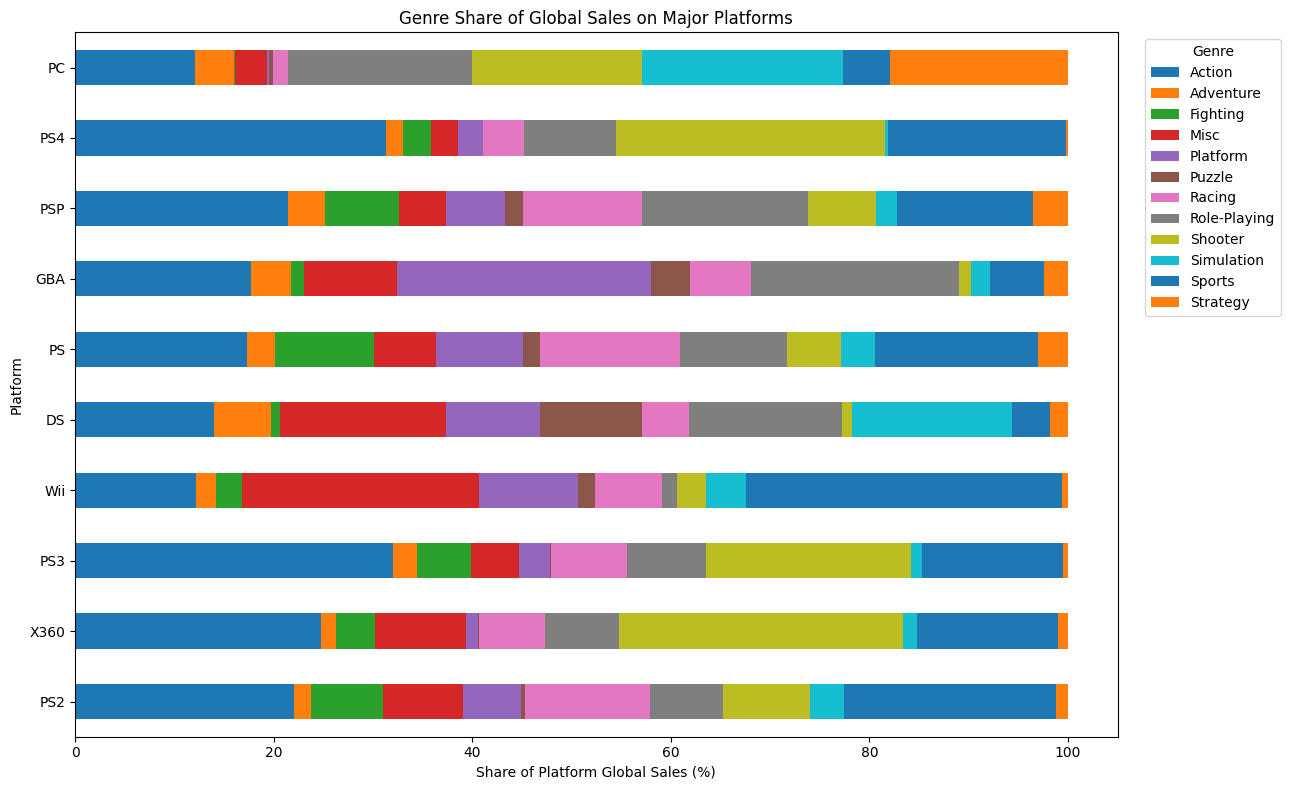

In [20]:
# Plot a 100% stacked horizontal bar chart
ax = sales_share_pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(13, 8)
)

ax.set_title("Genre Share of Global Sales on Major Platforms")
ax.set_xlabel("Share of Platform Global Sales (%)")
ax.set_ylabel("Platform")
ax.legend(
    title="Genre",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 8. Leading Genre on Each Major Platform

The leading genre on each major platform is identified using total global sales.

This allows the analysis to determine whether the same genres dominated across platforms or whether different platforms were associated with different genre strengths.

In [21]:
# Rank genres within each platform by total global sales
platform_genre_ranking = (
    platform_genre_sales
    .sort_values(
        ["platform", "total_global_sales"],
        ascending=[True, False]
    )
)

# Select the highest-selling genre for each platform
leading_genre_by_platform = (
    platform_genre_ranking
    .groupby("platform", as_index=False)
    .first()
)

# Calculate the number of games in each winning combination
leading_genre_counts = (
    major_platform_data
    .groupby(["platform", "genre"])
    .size()
    .reset_index(name="game_count")
)

leading_genre_by_platform = leading_genre_by_platform.merge(
    leading_genre_counts,
    on=["platform", "genre"],
    how="left"
)

# Calculate average sales for the leading genre on each platform
leading_genre_averages = (
    major_platform_data
    .groupby(["platform", "genre"], as_index=False)
    .agg(
        average_global_sales=("global_sales", "mean")
    )
)

leading_genre_by_platform = leading_genre_by_platform.merge(
    leading_genre_averages,
    on=["platform", "genre"],
    how="left"
)

leading_genre_by_platform = (
    leading_genre_by_platform
    .sort_values("total_global_sales", ascending=False)
)

leading_genre_by_platform[
    [
        "platform",
        "genre",
        "game_count",
        "total_global_sales",
        "average_global_sales",
        "sales_share"
    ]
].round(2)

,platform,genre,game_count,total_global_sales,average_global_sales,sales_share
5,PS3,Action,373,304.02,0.82,32.02
8,Wii,Sports,256,289.95,1.13,31.87
9,X360,Shooter,197,277.23,1.41,28.59
4,PS2,Action,345,272.43,0.79,22.09
0,DS,Misc,389,137.67,0.35,16.82
3,PS,Action,154,125.74,0.82,17.29
6,PS4,Action,122,87.06,0.71,31.31
1,GBA,Platform,139,78.08,0.56,25.55
7,PSP,Action,217,62.66,0.29,21.48
2,PC,Simulation,112,51.73,0.46,20.31


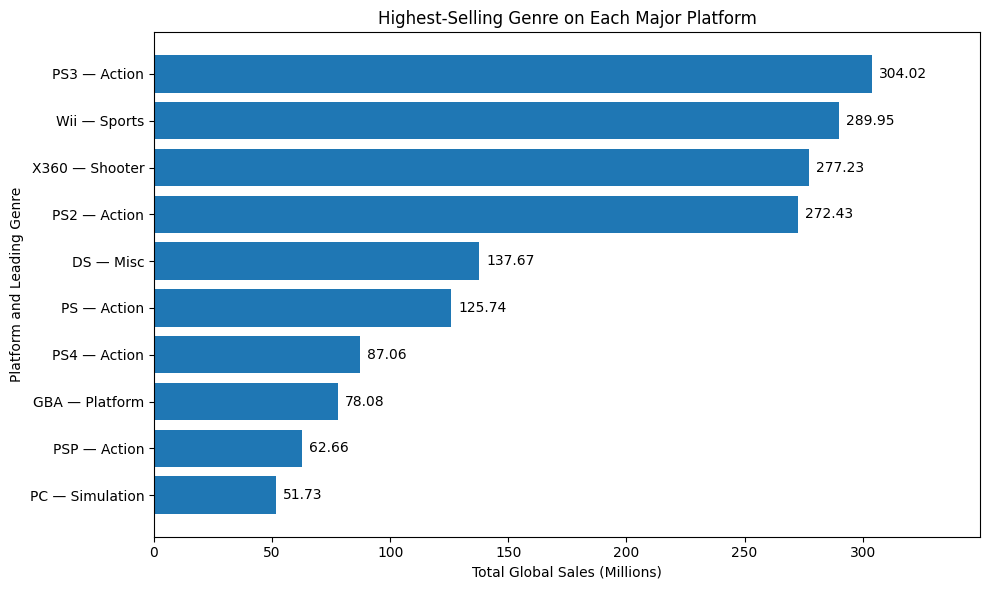

In [23]:
# Prepare labels for the chart
leading_plot_data = leading_genre_by_platform.copy()

leading_plot_data["platform_genre"] = (
    leading_plot_data["platform"]
    + " — "
    + leading_plot_data["genre"]
)

leading_plot_data = leading_plot_data.sort_values(
    "total_global_sales",
    ascending=True
)

plt.figure(figsize=(10, 6))

# Store the container returned by plt.barh()
bars = plt.barh(
    leading_plot_data["platform_genre"],
    leading_plot_data["total_global_sales"]
)

# Add values next to each bar
plt.bar_label(bars, fmt="%.2f", padding=5)

plt.title("Highest-Selling Genre on Each Major Platform")
plt.xlabel("Total Global Sales (Millions)")
plt.ylabel("Platform and Leading Genre")

# Extend x-axis limit slightly so the rightmost labels don't get cut off
plt.xlim(0, leading_plot_data["total_global_sales"].max() * 1.15)

plt.tight_layout()
plt.show()

### Top Three Genres on Each Major Platform

The highest-selling genre alone does not show whether a platform had a diverse genre profile.

The following table lists the three genres with the greatest total global sales on each major platform.

In [24]:
# Assign a sales rank to genres within every platform
platform_genre_ranking["genre_rank"] = (
    platform_genre_ranking
    .groupby("platform")["total_global_sales"]
    .rank(
        method="first",
        ascending=False
    )
)

top_three_genres = (
    platform_genre_ranking[
        platform_genre_ranking["genre_rank"] <= 3
    ]
    .sort_values(["platform", "genre_rank"])
    .copy()
)

top_three_genres[
    [
        "platform",
        "genre_rank",
        "genre",
        "total_global_sales",
        "sales_share"
    ]
].round(2)

,platform,genre_rank,genre,total_global_sales,sales_share
3,DS,1.0,Misc,137.67,16.82
9,DS,2.0,Simulation,131.36,16.05
7,DS,3.0,Role-Playing,126.56,15.46
16,GBA,1.0,Platform,78.08,25.55
19,GBA,2.0,Role-Playing,64.21,21.01
12,GBA,3.0,Action,54.26,17.75
33,PC,1.0,Simulation,51.73,20.31
31,PC,2.0,Role-Playing,47.37,18.60
35,PC,3.0,Strategy,45.63,17.92
36,PS,1.0,Action,125.74,17.29


In [25]:
# Display the top three genres in a more compact format
top_three_genres_display = (
    top_three_genres
    .assign(
        genre_summary=lambda data:
            data["genre"]
            + " ("
            + data["total_global_sales"].round(2).astype(str)
            + "M)"
    )
    .pivot(
        index="platform",
        columns="genre_rank",
        values="genre_summary"
    )
    .rename(
        columns={
            1.0: "First",
            2.0: "Second",
            3.0: "Third"
        }
    )
)

top_three_genres_display

genre_rank,First,Second,Third
platform,,,
DS,Misc (137.67M),Simulation (131.36M),Role-Playing (126.56M)
GBA,Platform (78.08M),Role-Playing (64.21M),Action (54.26M)
PC,Simulation (51.73M),Role-Playing (47.37M),Strategy (45.63M)
PS,Action (125.74M),Sports (119.51M),Racing (102.89M)
PS2,Action (272.43M),Sports (262.64M),Racing (154.21M)
PS3,Action (304.02M),Shooter (195.8M),Sports (134.91M)
PS4,Action (87.06M),Shooter (75.32M),Sports (50.07M)
PSP,Action (62.66M),Role-Playing (49.01M),Sports (39.9M)
Wii,Sports (289.95M),Misc (217.43M),Action (110.48M)


## 9. Release Volume Versus Sales Performance

A genre-platform combination may generate high total sales because it contains many games, because its individual games sell strongly, or because of both factors.

The following scatter plot compares the number of games released with average global sales per game.

Bubble size represents total global sales.

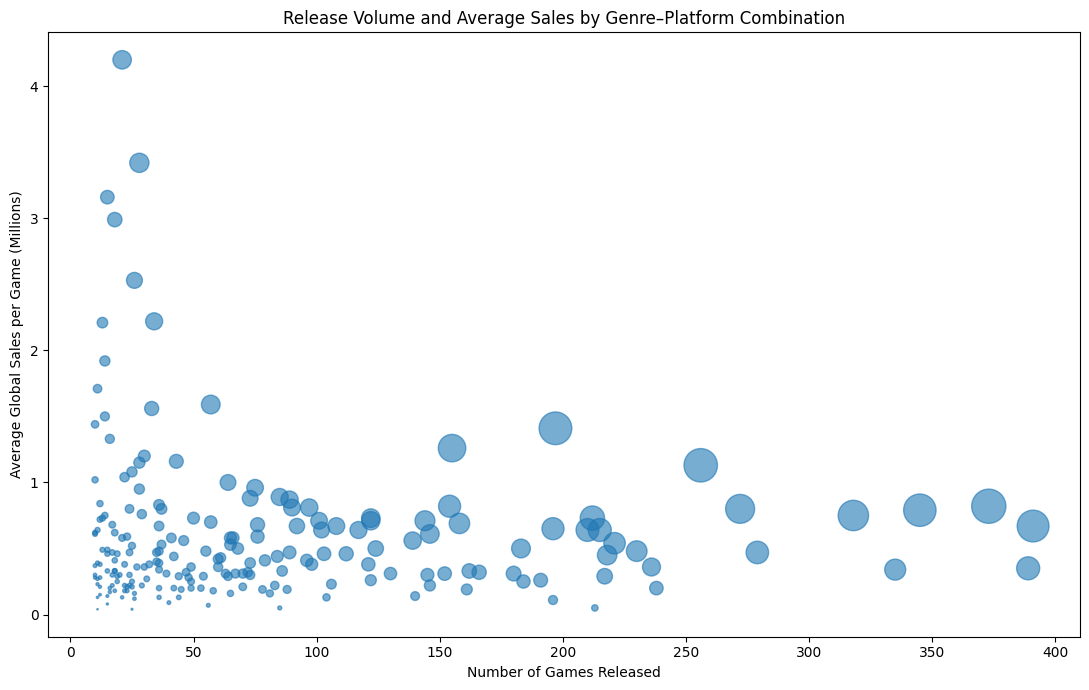

In [26]:
# Use the reliable combinations created earlier
scatter_data = reliable_combinations.copy()

plt.figure(figsize=(11, 7))

plt.scatter(
    scatter_data["game_count"],
    scatter_data["average_global_sales"],
    s=scatter_data["total_global_sales"] * 2,
    alpha=0.6
)

plt.title("Release Volume and Average Sales by Genre–Platform Combination")
plt.xlabel("Number of Games Released")
plt.ylabel("Average Global Sales per Game (Millions)")

plt.tight_layout()
plt.show()

In [27]:
# Calculate the relationship between release volume and sales measures
volume_average_correlation = (
    reliable_combinations["game_count"]
    .corr(reliable_combinations["average_global_sales"])
)

volume_total_correlation = (
    reliable_combinations["game_count"]
    .corr(reliable_combinations["total_global_sales"])
)

print(
    "Correlation between game count and average sales: "
    f"{volume_average_correlation:.3f}"
)

print(
    "Correlation between game count and total sales: "
    f"{volume_total_correlation:.3f}"
)

Correlation between game count and average sales: -0.070
Correlation between game count and total sales: 0.806


The correlations should be interpreted carefully.

A positive relationship between release count and total sales is expected because combinations with more games have more opportunities to accumulate sales.

The relationship between release count and average sales is more informative because it indicates whether larger catalogues were also associated with stronger performance per game.

## 10. High-Volume and High-Performance Combinations

To identify combinations that performed strongly across multiple measures, genre-platform combinations are compared against the median release count and median average sales.

This separates the combinations into four broad groups:

- High volume and high average sales
- High volume and low average sales
- Low volume and high average sales
- Low volume and low average sales

In [28]:
# Calculate median thresholds
median_game_count = reliable_combinations["game_count"].median()
median_average_sales = reliable_combinations[
    "average_global_sales"
].median()

print(f"Median game count: {median_game_count:.1f}")
print(f"Median average sales: {median_average_sales:.2f} million")

Median game count: 46.0
Median average sales: 0.41 million


In [29]:
def classify_combination(row):
    if (
        row["game_count"] >= median_game_count
        and row["average_global_sales"] >= median_average_sales
    ):
        return "High Volume / High Average Sales"

    if (
        row["game_count"] >= median_game_count
        and row["average_global_sales"] < median_average_sales
    ):
        return "High Volume / Low Average Sales"

    if (
        row["game_count"] < median_game_count
        and row["average_global_sales"] >= median_average_sales
    ):
        return "Low Volume / High Average Sales"

    return "Low Volume / Low Average Sales"


performance_segments = reliable_combinations.copy()

performance_segments["performance_group"] = (
    performance_segments.apply(
        classify_combination,
        axis=1
    )
)

performance_segments.head()

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales,performance_group
0,2600,Action,55,26.39,0.48,0.38,High Volume / High Average Sales
7,2600,Shooter,22,22.97,1.04,0.75,Low Volume / High Average Sales
9,2600,Sports,10,2.77,0.28,0.24,Low Volume / Low Average Sales
13,3DS,Action,180,56.61,0.31,0.11,High Volume / Low Average Sales
14,3DS,Adventure,36,4.73,0.13,0.06,Low Volume / Low Average Sales


In [30]:
# Count combinations in each performance group
performance_group_counts = (
    performance_segments["performance_group"]
    .value_counts()
    .rename_axis("performance_group")
    .reset_index(name="combination_count")
)

performance_group_counts

,performance_group,combination_count
0,High Volume / High Average Sales,56
1,Low Volume / Low Average Sales,54
2,Low Volume / High Average Sales,49
3,High Volume / Low Average Sales,48


In [31]:
# Display combinations that are strong in both volume and average sales
high_volume_high_performance = (
    performance_segments[
        performance_segments["performance_group"]
        == "High Volume / High Average Sales"
    ]
    .sort_values(
        "total_global_sales",
        ascending=False
    )
)

high_volume_high_performance[
    [
        "platform",
        "genre",
        "game_count",
        "total_global_sales",
        "average_global_sales",
        "median_global_sales"
    ]
].head(20)

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
153,PS3,Action,373,304.02,0.82,0.32
244,Wii,Sports,256,289.95,1.13,0.23
266,X360,Shooter,197,277.23,1.41,0.41
141,PS2,Action,345,272.43,0.79,0.36
151,PS2,Sports,391,262.64,0.67,0.31
258,X360,Action,318,239.67,0.75,0.30
237,Wii,Misc,272,217.43,0.80,0.24
161,PS3,Shooter,155,195.80,1.26,0.57
147,PS2,Racing,212,154.21,0.73,0.26
268,X360,Sports,215,137.43,0.64,0.30


## 11. Mean and Median Sales Comparison

Average sales can be increased by a small number of blockbuster games.

Median sales provide a more resistant measure of typical performance because they are less affected by extreme values.

Comparing the mean and median helps identify genre-platform combinations whose average may be driven by a limited number of unusually successful titles.

In [32]:
mean_median_comparison = reliable_combinations.copy()

mean_median_comparison["mean_median_difference"] = (
    mean_median_comparison["average_global_sales"]
    - mean_median_comparison["median_global_sales"]
)

mean_median_comparison["mean_to_median_ratio"] = (
    mean_median_comparison["average_global_sales"]
    / mean_median_comparison["median_global_sales"].replace(0, np.nan)
)

mean_median_comparison = mean_median_comparison.sort_values(
    "mean_median_difference",
    ascending=False
)

mean_median_comparison[
    [
        "platform",
        "genre",
        "game_count",
        "average_global_sales",
        "median_global_sales",
        "mean_median_difference",
        "mean_to_median_ratio"
    ]
].head(15).round(2)

,platform,genre,game_count,average_global_sales,median_global_sales,mean_median_difference,mean_to_median_ratio
52,GB,Role-Playing,21,4.20,0.76,3.44,5.53
108,NES,Platform,28,3.42,1.18,2.24,2.90
50,GB,Puzzle,15,3.16,1.15,2.01,2.75
222,SNES,Platform,26,2.53,0.60,1.93,4.22
238,Wii,Platform,57,1.59,0.33,1.26,4.82
19,3DS,Racing,10,1.44,0.21,1.23,6.86
266,X360,Shooter,197,1.41,0.41,1.00,3.44
173,PS4,Shooter,34,2.22,1.26,0.96,1.76
17,3DS,Platform,28,1.15,0.21,0.94,5.48
244,Wii,Sports,256,1.13,0.23,0.90,4.91


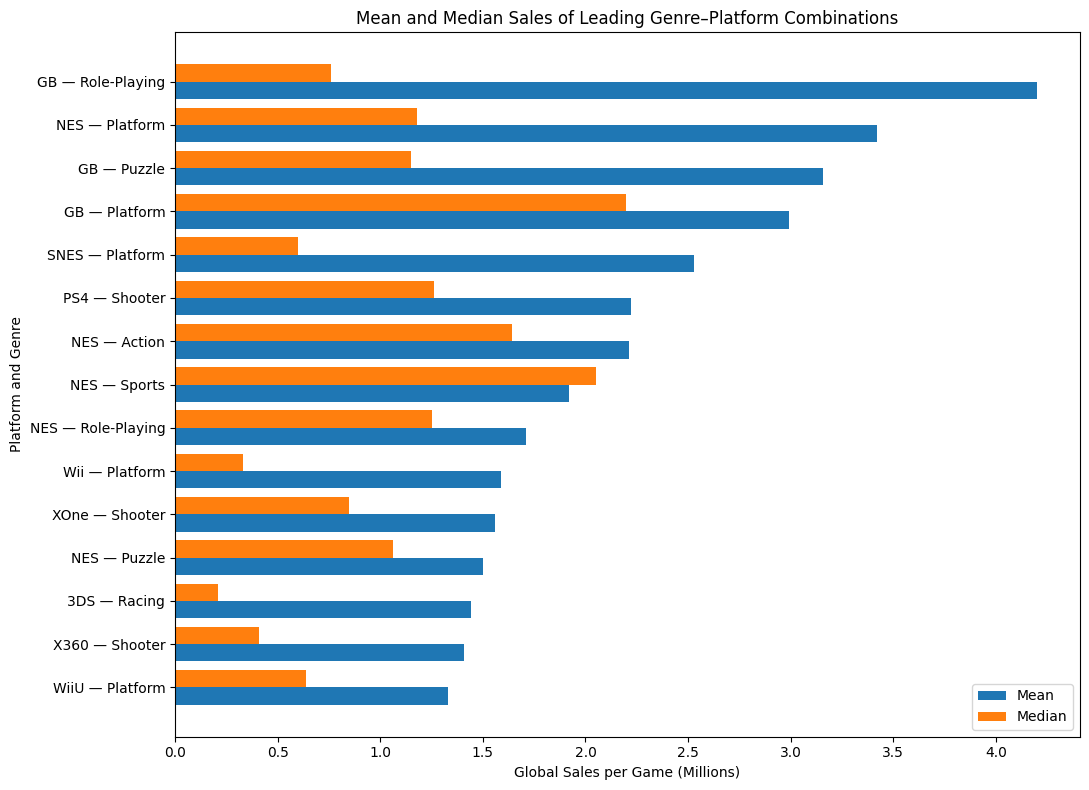

In [33]:
# Select the 15 combinations with the highest average sales
mean_median_plot_data = (
    reliable_combinations
    .sort_values("average_global_sales", ascending=False)
    .head(15)
    .copy()
)

mean_median_plot_data["genre_platform"] = (
    mean_median_plot_data["platform"]
    + " — "
    + mean_median_plot_data["genre"]
)

mean_median_plot_data = mean_median_plot_data.sort_values(
    "average_global_sales",
    ascending=True
)

y_positions = np.arange(len(mean_median_plot_data))

plt.figure(figsize=(11, 8))

plt.barh(
    y_positions - 0.2,
    mean_median_plot_data["average_global_sales"],
    height=0.4,
    label="Mean"
)

plt.barh(
    y_positions + 0.2,
    mean_median_plot_data["median_global_sales"],
    height=0.4,
    label="Median"
)

plt.yticks(
    y_positions,
    mean_median_plot_data["genre_platform"]
)

plt.title("Mean and Median Sales of Leading Genre–Platform Combinations")
plt.xlabel("Global Sales per Game (Millions)")
plt.ylabel("Platform and Genre")
plt.legend()

plt.tight_layout()
plt.show()

## 12. Key Results Summary

The following tables summarize the strongest genre-platform combinations using different definitions of performance.

No single measure provides a complete answer:

- Total sales represent overall commercial contribution.
- Average sales represent sales efficiency per game.
- Median sales represent the performance of a more typical game.
- Game count represents release volume.

In [34]:
# Top 10 combinations by total global sales
final_top_total = (
    reliable_combinations
    .nlargest(10, "total_global_sales")
    [
        [
            "platform",
            "genre",
            "game_count",
            "total_global_sales",
            "average_global_sales",
            "median_global_sales"
        ]
    ]
)

final_top_total

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
153,PS3,Action,373,304.02,0.82,0.32
244,Wii,Sports,256,289.95,1.13,0.23
266,X360,Shooter,197,277.23,1.41,0.41
141,PS2,Action,345,272.43,0.79,0.36
151,PS2,Sports,391,262.64,0.67,0.31
258,X360,Action,318,239.67,0.75,0.30
237,Wii,Misc,272,217.43,0.80,0.24
161,PS3,Shooter,155,195.80,1.26,0.57
147,PS2,Racing,212,154.21,0.73,0.26
37,DS,Misc,389,137.67,0.35,0.10


In [35]:
# Top 10 combinations by average global sales
final_top_average = (
    reliable_combinations
    .nlargest(10, "average_global_sales")
    [
        [
            "platform",
            "genre",
            "game_count",
            "total_global_sales",
            "average_global_sales",
            "median_global_sales"
        ]
    ]
)

final_top_average

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
52,GB,Role-Playing,21,88.24,4.20,0.76
108,NES,Platform,28,95.78,3.42,1.18
50,GB,Puzzle,15,47.47,3.16,1.15
49,GB,Platform,18,53.88,2.99,2.20
222,SNES,Platform,26,65.65,2.53,0.60
173,PS4,Shooter,34,75.32,2.22,1.26
104,NES,Action,13,28.75,2.21,1.64
113,NES,Sports,14,26.85,1.92,2.05
111,NES,Role-Playing,11,18.78,1.71,1.25
238,Wii,Platform,57,90.68,1.59,0.33


In [36]:
# Top 10 combinations by median global sales
final_top_median = (
    reliable_combinations
    .nlargest(10, "median_global_sales")
    [
        [
            "platform",
            "genre",
            "game_count",
            "total_global_sales",
            "average_global_sales",
            "median_global_sales"
        ]
    ]
)

final_top_median

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
49,GB,Platform,18,53.88,2.99,2.20
113,NES,Sports,14,26.85,1.92,2.05
104,NES,Action,13,28.75,2.21,1.64
173,PS4,Shooter,34,75.32,2.22,1.26
111,NES,Role-Playing,11,18.78,1.71,1.25
108,NES,Platform,28,95.78,3.42,1.18
50,GB,Puzzle,15,47.47,3.16,1.15
109,NES,Puzzle,14,21.00,1.50,1.06
289,XOne,Shooter,33,51.61,1.56,0.85
52,GB,Role-Playing,21,88.24,4.20,0.76
